In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!unrar x -y "/content/drive/MyDrive/ML_Project/emergency/emergency_dataset_with_label.rar" /content/dataset/

In [3]:
import os
import glob
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

data_dir = '/content/dataset/data2'
image_dir = os.path.join(data_dir, 'images')
label_dir = os.path.join(data_dir, 'labels')

records = []

image_paths = glob.glob(os.path.join(image_dir, '*.[jJ][pP][gG]')) + \
              glob.glob(os.path.join(image_dir, '*.[pP][nN][gG]')) + \
              glob.glob(os.path.join(image_dir, '*.[jJ][pP][eE][gG]'))

for img_p in image_paths:
    base_name = os.path.splitext(os.path.basename(img_p))[0]
    txt_p = os.path.join(label_dir, f"{base_name}.txt")

    if os.path.exists(txt_p):
        with open(txt_p, 'r') as f:
            lines = f.readlines()
            if lines:
                class_id = int(lines[0].strip().split()[0])
                records.append({'image_path': img_p, 'label': class_id})

df = pd.DataFrame(records)
print(f"Total labeled images found: {len(df)}")
print("Class distribution:")
print(df['label'].value_counts())

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

print(f"\nTrain set: {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")
print(f"Test set: {len(test_df)} images")

class EmergencyVehicleDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'label']
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

IMAGE_SIZE = 128
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = EmergencyVehicleDataset(train_df, transform=train_transforms)
val_dataset = EmergencyVehicleDataset(val_df, transform=val_test_transforms)
test_dataset = EmergencyVehicleDataset(test_df, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("\nDataLoaders are ready.")

Total labeled images found: 1170
Class distribution:
label
1    922
0    248
Name: count, dtype: int64

Train set: 819 images
Validation set: 175 images
Test set: 176 images

DataLoaders are ready.


In [4]:
import torch.nn as nn
import torch.nn.functional as F

class EmergencyCNN(nn.Module):
    def __init__(self):
        super(EmergencyCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        logits = self.classifier(x)
        return logits

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EmergencyCNN().to(device)

print(f"Using device: {device}")
print(model)


Using device: cuda
EmergencyCNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (

In [5]:
import torch.optim as optim
import copy
import torch.nn as nn
import torch

class_weights = torch.tensor([922.0 / 248.0, 1.0], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)

NUM_EPOCHS = 20
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
best_model_weights = copy.deepcopy(model.state_dict())

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels).item()
        total_train += labels.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels).item()
            total_val += labels.size(0)

    epoch_val_loss = val_running_loss / total_val
    epoch_val_acc = correct_val / total_val

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

model.load_state_dict(best_model_weights)
torch.save(model.state_dict(), 'best_emergency_cnn.pth')


Epoch [1/20] Train Loss: 0.8795 Acc: 0.7937 | Val Loss: 0.3592 Acc: 0.8514
Epoch [2/20] Train Loss: 0.3431 Acc: 0.8803 | Val Loss: 0.3726 Acc: 0.9029
Epoch [3/20] Train Loss: 0.2464 Acc: 0.9121 | Val Loss: 0.3307 Acc: 0.9086
Epoch [4/20] Train Loss: 0.1957 Acc: 0.9328 | Val Loss: 0.3287 Acc: 0.8857
Epoch [5/20] Train Loss: 0.1914 Acc: 0.9170 | Val Loss: 0.4041 Acc: 0.9200
Epoch [6/20] Train Loss: 0.1549 Acc: 0.9426 | Val Loss: 0.4193 Acc: 0.9200
Epoch [7/20] Train Loss: 0.1297 Acc: 0.9524 | Val Loss: 0.3767 Acc: 0.9086
Epoch [8/20] Train Loss: 0.1897 Acc: 0.9267 | Val Loss: 0.5052 Acc: 0.8686
Epoch [9/20] Train Loss: 0.2009 Acc: 0.9170 | Val Loss: 0.3411 Acc: 0.9257
Epoch [10/20] Train Loss: 0.1082 Acc: 0.9585 | Val Loss: 0.4061 Acc: 0.8971
Epoch [11/20] Train Loss: 0.0936 Acc: 0.9585 | Val Loss: 0.4049 Acc: 0.9257
Epoch [12/20] Train Loss: 0.0995 Acc: 0.9658 | Val Loss: 0.4794 Acc: 0.8971
Epoch [13/20] Train Loss: 0.0810 Acc: 0.9707 | Val Loss: 0.5136 Acc: 0.9371
Epoch [14/20] Train L

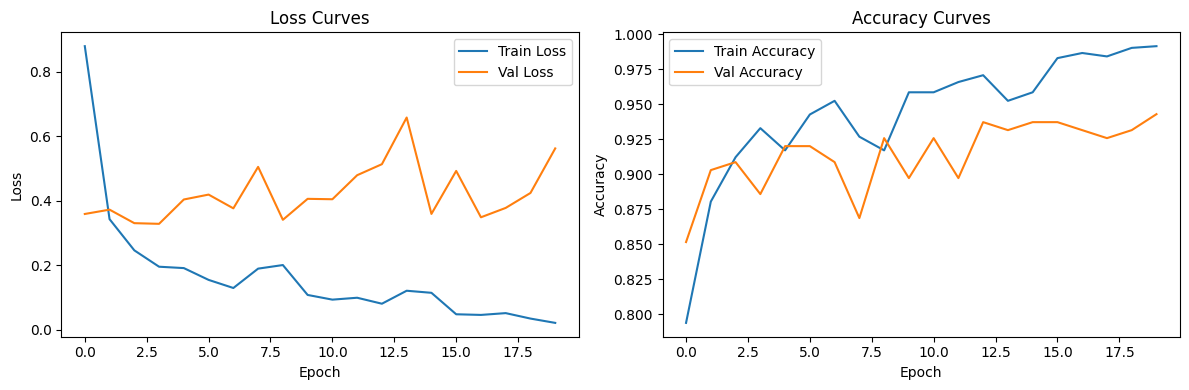

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curves')

plt.tight_layout()
plt.show()

Classification Report:
                   precision    recall  f1-score   support

Non-Emergency (0)     0.8780    0.9730    0.9231        37
    Emergency (1)     0.9926    0.9640    0.9781       139

         accuracy                         0.9659       176
        macro avg     0.9353    0.9685    0.9506       176
     weighted avg     0.9685    0.9659    0.9665       176



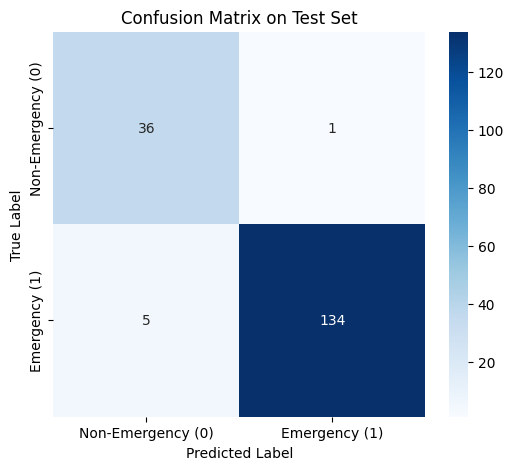

In [7]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

target_names = ['Non-Emergency (0)', 'Emergency (1)']

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()
